# Diabetic Retinopathy Stage Detection

Five-grade ICDR classification (0 No DR, 1 Mild, 2 Moderate, 3 Severe, 4 Proliferative DR) with
transfer learning on EfficientNetV2-B0. Trained on **DDR**, tested on a held-out DDR split and on
**IDRiD** as an external dataset the model never sees.

**How to run:** set the options in **0.2 Config**, then *Run All*. To try another setting (for example
`TRAIN_SIZE = 4000`), edit 0.2, run 0.2, then run from **3.1** to the end. Every run is saved under
`/kaggle/working/runs/<RUN_TAG>/` and 6.7 compares all runs found.

**Kaggle settings:** GPU T4, Internet on, Persistence = *Files only*.

---
## 0. Setup

In [ ]:
# 0.1 Imports, GPU and mixed precision
import os, re, json, time, shutil, pathlib, subprocess, warnings
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (classification_report, confusion_matrix, cohen_kappa_score,
                             accuracy_score, f1_score, recall_score, roc_auc_score)

try:
    import imagehash
except ImportError:
    subprocess.run(['pip', '-q', 'install', 'imagehash'], check=True)
    import imagehash

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore', category=UserWarning)
cv2.setNumThreads(1)          
pd.set_option('display.width', 160)

LABELS = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferative_DR']
WEIGHTS = 'imagenet'          

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow', tf.__version__, '| Keras', keras.__version__)
print('GPU:', [g.name for g in gpus] or 'none - training will be very slow')
if gpus:
    cc = tf.config.experimental.get_device_details(gpus[0]).get('compute_capability')
    if cc and cc >= (7, 0):
        keras.mixed_precision.set_global_policy('mixed_float16')
print('precision policy:', keras.mixed_precision.global_policy().name)

TensorFlow 2.20.0 | Keras 3.13.2
GPU: ['/physical_device:GPU:0', '/physical_device:GPU:1']
precision policy: mixed_float16


In [ ]:
# 0.2 Config
class Config:
    # data 
    TRAIN_SIZE = 'full'                # 2000 | 4000 | 8000 | 'full'
    SPLIT      = (0.70, 0.15, 0.15)    # train / val / test share of DDR
    SEED       = 42
    IMG_SIZE   = 512                   
    BATCH_SIZE = 32
    NORM       = 'none'                # 'none' | 'clahe'

    # model 
    HEAD       = 'dense'               # 'dense' = GAP-BN-Dropout-Dense(256)-Dropout-Dense(5)
                                       # 'simple' = GAP-Dropout-Dense(5)
    DROPOUT    = 0.3
    UNFREEZE   = 0.50                  

    # training 
    LOSS          = 'focal'            # 'focal' | 'ce_weighted'
    FOCAL_GAMMA   = 2.0
    PHASE1_EPOCHS = 5                  
    PHASE1_LR     = 1e-3
    PHASE2_EPOCHS = 30                 
    PHASE2_LR     = 1e-4
    PHASE3_WEAK_CLASSES = True         
    PHASE3_TARGETS      = (1, 3)       
    PHASE3_EPOCHS       = 6
    PHASE3_LR           = 3e-5         
    ES_PATIENCE   = 5                  
    RLR_PATIENCE  = 2                  
    RLR_FACTOR    = 0.3
    CLEAN_N       = 500                

    # augmentation 
    ROTATION   = 360                   
    ZOOM       = (0.90, 1.10)
    BRIGHTNESS = 0.20                  
    CONTRAST   = 0.10                  
    CHANNEL    = 0.05                  

    # preprocessing 
    CACHE_SIZE = 512
    MASK_FRAC  = 0.95                  

    RUN_TAG = f'{TRAIN_SIZE}_{HEAD}_{NORM}_{LOSS}_{IMG_SIZE}' + ('_p3' if PHASE3_WEAK_CLASSES else '')
    
C = Config
print('run tag:', C.RUN_TAG)
print({k: v for k, v in vars(Config).items() if not k.startswith('_')})

run tag: full_dense_none_focal_512
{'TRAIN_SIZE': 'full', 'SPLIT': (0.7, 0.15, 0.15), 'SEED': 42, 'IMG_SIZE': 512, 'BATCH_SIZE': 32, 'NORM': 'none', 'HEAD': 'dense', 'DROPOUT': 0.3, 'UNFREEZE': 0.5, 'LOSS': 'focal', 'FOCAL_GAMMA': 2.0, 'PHASE1_EPOCHS': 5, 'PHASE1_LR': 0.001, 'PHASE2_EPOCHS': 30, 'PHASE2_LR': 0.0001, 'ES_PATIENCE': 5, 'RLR_PATIENCE': 2, 'RLR_FACTOR': 0.3, 'CLEAN_N': 500, 'ROTATION': 360, 'ZOOM': (0.9, 1.1), 'BRIGHTNESS': 0.2, 'CONTRAST': 0.1, 'CHANNEL': 0.05, 'CACHE_SIZE': 512, 'MASK_FRAC': 0.95, 'RUN_TAG': 'full_dense_none_focal_512'}


In [ ]:
# 0.3 Paths and input files
INPUT = pathlib.Path('/kaggle/input')
WORK  = pathlib.Path('/kaggle/working')
RUNS  = WORK / 'runs'
RUNS.mkdir(parents=True, exist_ok=True)

def find_input(pattern):
    hits = sorted(INPUT.rglob(pattern))
    return hits[0] if hits else None

def need_input(pattern):
    p = find_input(pattern)
    assert p is not None, f'{pattern} not found under /kaggle/input - add the dataset to the notebook'
    return p

DDR_CSV   = need_input('DR_grading.csv')
IDRID_CSV = need_input('idrid_labels.csv')
OFF_TRAIN = need_input('*IDRiD_Disease_Grading_Training_Labels.csv')
OFF_TEST  = need_input('*IDRiD_Disease_Grading_Testing_Labels.csv')
DDR_IMG   = DDR_CSV.parent / 'DR_grading' / 'DR_grading'
IDRID_IMG = IDRID_CSV.parent / 'Imagenes' / 'Imagenes'
for p in (DDR_IMG, IDRID_IMG):
    assert p.is_dir(), f'image folder not found: {p}'

CACHE_SPEC = {'out_size': C.CACHE_SIZE, 'mask_frac': C.MASK_FRAC}
PROC = WORK / 'processed'
for m in INPUT.rglob('manifest.json'):
    try:
        spec = json.loads(m.read_text())
    except Exception:
        continue
    if {k: spec.get(k) for k in CACHE_SPEC} == CACHE_SPEC and (m.parent / 'ddr').is_dir():
        PROC = m.parent
        break

print('DDR   :', DDR_CSV.parent)
print('IDRiD :', IDRID_CSV.parent)
print('cache :', PROC, '(attached input)' if str(PROC).startswith(str(INPUT)) else '(built in 2.3 if missing)')

DDR   : /kaggle/input/datasets/mariaherrerot/ddrdataset
IDRiD : /kaggle/input/datasets/mariaherrerot/idrid-dataset
cache : /kaggle/working/processed (built in 2.3 if missing)


---
## 1. Dataset
DDR (147 hospitals, 12,522 images) is used for training, validation and internal testing. IDRiD
(one clinic, 455 images) is kept entirely for external testing. Both use the ICDR 0-4 scale.

IDRiD labels corrected: 27 of 455
                   DDR  IDRiD  DDR %  IDRiD %
No_DR             6266    118   50.0     25.9
Mild               630     23    5.0      5.1
Moderate          4477    164   35.8     36.0
Severe             236     90    1.9     19.8
Proliferative_DR   913     60    7.3     13.2

DDR imbalance (largest / smallest class): 26.6 : 1


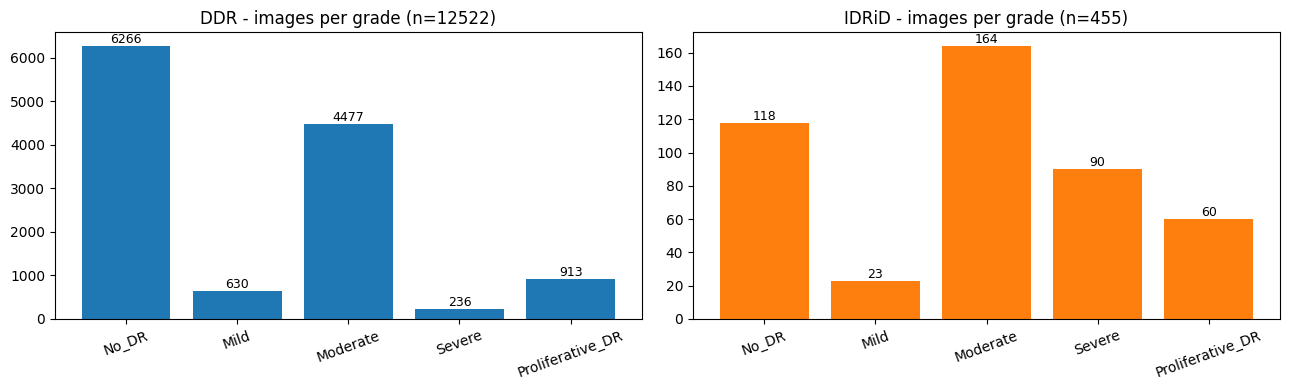

In [ ]:
# 1.1 Load labels, correct IDRiD, class distribution
ddr = pd.read_csv(DDR_CSV)[['id_code', 'diagnosis']]
ddr['source'] = np.where(ddr['id_code'].str.match(r'^\d{3}-\d{4}-\d{3}'), 'hyphen', 'timestamp')
on_disk = {p.name for p in DDR_IMG.iterdir()}
assert ddr['id_code'].isin(on_disk).all(), 'some labelled DDR images are missing'

idr = pd.read_csv(IDRID_CSV)
idr = idr.loc[:, ~idr.columns.str.startswith('Unnamed')].iloc[:, :2].set_axis(['id_code', 'rehost'], axis=1)
idr['split'] = np.where(idr['id_code'].str.endswith('test'), 'test', 'train')

official = pd.concat([pd.read_csv(p).iloc[:, :2].set_axis(['name', 'diagnosis'], axis=1).assign(split=s)
                      for s, p in (('train', OFF_TRAIN), ('test', OFF_TEST))], ignore_index=True)
official['name'] = official['name'].astype(str).str.strip()
idr = (idr.assign(name=idr['id_code'].str.replace('test', '', regex=False))
          .merge(official, on=['name', 'split'], how='left'))
assert idr['diagnosis'].notna().all(), 'IDRiD images without an official label'
idr['diagnosis'] = idr['diagnosis'].astype(int)
print(f"IDRiD labels corrected: {(idr['rehost'] != idr['diagnosis']).sum()} of {len(idr)}")
idr = idr[['id_code', 'diagnosis']]

counts = pd.DataFrame({'DDR': ddr['diagnosis'].value_counts().sort_index(),
                       'IDRiD': idr['diagnosis'].value_counts().sort_index()}).fillna(0).astype(int)
counts.index = LABELS
table = counts.assign(**{'DDR %': (counts['DDR'] / counts['DDR'].sum() * 100).round(1),
                         'IDRiD %': (counts['IDRiD'] / counts['IDRiD'].sum() * 100).round(1)})
print(table.to_string())
print(f"\nDDR imbalance (largest / smallest class): {counts['DDR'].max() / counts['DDR'].min():.1f} : 1")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, colour in zip(axes, ['DDR', 'IDRiD'], ['tab:blue', 'tab:orange']):
    ax.bar(LABELS, counts[col], color=colour)
    for i, v in enumerate(counts[col]):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{col} - images per grade (n={counts[col].sum()})')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

In [ ]:
# 1.2 Sample images per grade (raw, before preprocessing)
rng = np.random.default_rng(C.SEED)
fig, axes = plt.subplots(2, 5, figsize=(18, 7.5))
for g in range(5):
    for row, (name, frame, folder, ext) in enumerate([('DDR', ddr, DDR_IMG, ''), ('IDRiD', idr, IDRID_IMG, '.jpg')]):
        ids = frame.loc[frame['diagnosis'] == g, 'id_code'].to_numpy()
        with Image.open(folder / f'{rng.choice(ids)}{ext}') as im:
            im.thumbnail((400, 400))
            axes[row, g].imshow(im)
        axes[row, g].set_title(f'{name} - {LABELS[g]}', fontsize=10)
        axes[row, g].axis('off')
plt.suptitle('Raw fundus images, one per grade', y=1.0)
plt.tight_layout(); plt.show()

### 1.3 Key findings carried over from the full dataset analysis
- **Imbalance:** DDR is 50.0% No DR and 1.9% Severe (26.6 : 1). Accuracy alone is misleading, so
  QWK, macro F1 and per-class recall are reported.
- **Two capture sources:** filename style (hyphen / timestamp) separates two groups with very different
  grade mixes (hyphen holds 99.9% of PDR). Splits keep the same source mix per grade.
- **Near-duplicates:** 30 groups (65 images) of near-identical photos, found with a 256-bit perceptual
  hash. Each group is kept inside one split so no test image has a copy in training.
- **IDRiD labels:** the Kaggle rehost disagrees with the official labels on 27 images (5.9%);
  official labels are used.
- **Prevalence gap:** Severe is 1.9% of DDR but 19.8% of IDRiD, so IDRiD gives a meaningful
  Severe recall.
- **Ethics and limits:** de-identified public data, labels from graders who can disagree on Mild vs
  Moderate, populations limited to China (DDR) and India (IDRiD).

---
## 2. Preprocessing
Each image: find the round retina, apply a circular mask at 95% of its radius, crop to a square and
resize to 512 px. This runs **once** and is saved. Contrast enhancement (CLAHE) is optional
(`Config.NORM`) and is applied when images are loaded.

In [ ]:
# 2.1 Preprocessing functions
def detect_fov(img, thresh=12, work=512):
    s = work / max(img.shape[:2])
    sm = cv2.resize(img, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    m = (sm.max(2) > thresh).astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    x, y, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    return (x + w / 2) / s, (y + h / 2) / s, max(w, h) / 2 / s

def circle_mask(side, frac=1.0):
    yy, xx = np.ogrid[:side, :side]
    c = side / 2
    return (xx - c) ** 2 + (yy - c) ** 2 <= (c * frac) ** 2

def preprocess(path, out=C.CACHE_SIZE, mask_frac=C.MASK_FRAC):
    img = cv2.imread(str(path))
    if img is None:
        return None
    fov = detect_fov(img)
    if fov is None:
        return None
    cx, cy, r = fov
    r *= mask_frac
    side = int(round(2 * r))
    x0, y0 = int(round(cx - r)), int(round(cy - r))
    canvas = np.zeros((side, side, 3), np.uint8)          
    sx0, sy0 = max(x0, 0), max(y0, 0)
    sx1, sy1 = min(x0 + side, img.shape[1]), min(y0 + side, img.shape[0])
    canvas[sy0 - y0:sy1 - y0, sx0 - x0:sx1 - x0] = img[sy0:sy1, sx0:sx1]
    canvas[~circle_mask(side)] = 0
    interp = cv2.INTER_AREA if side > out else cv2.INTER_CUBIC
    return cv2.resize(canvas, (out, out), interpolation=interp)

_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def apply_clahe(img):
    black = img.max(2) == 0
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = _clahe.apply(lab[:, :, 0])
    out = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    out[black] = 0                                        
    return out

print('preprocessing functions ready')

preprocessing functions ready


In [ ]:
# 2.2 Before / after: raw -> cropped and masked -> CLAHE
examples = [('DDR', DDR_IMG / ddr['id_code'].iloc[0]),
            ('DDR', DDR_IMG / ddr.loc[ddr['diagnosis'] == 4, 'id_code'].iloc[0]),
            ('IDRiD', IDRID_IMG / f"{idr['id_code'].iloc[0]}.jpg"),
            ('IDRiD', IDRID_IMG / f"{idr.loc[idr['diagnosis'] == 3, 'id_code'].iloc[0]}.jpg")]

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for col, (name, path) in enumerate(examples):
    with Image.open(path) as im:
        axes[0, col].imshow(im.resize((400, int(400 * im.size[1] / im.size[0]))))
        axes[0, col].set_title(f'{name} raw {im.size[0]}x{im.size[1]}', fontsize=10)
    out = preprocess(path)
    enh = apply_clahe(out)
    axes[1, col].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB)); axes[1, col].set_title('crop + mask, 512 px')
    axes[2, col].imshow(cv2.cvtColor(enh, cv2.COLOR_BGR2RGB)); axes[2, col].set_title('+ CLAHE')
    inside = circle_mask(out.shape[0], 0.98)
    axes[3, col].hist(out[:, :, 1][inside], bins=64, alpha=0.6, label='before')
    axes[3, col].hist(enh[:, :, 1][inside], bins=64, alpha=0.6, label='CLAHE')
    axes[3, col].set_title('green channel inside retina'); axes[3, col].legend(fontsize=8)
    for r in range(3):
        axes[r, col].axis('off')
    assert out.shape == (C.CACHE_SIZE, C.CACHE_SIZE, 3) and out[:8, :8].max() == 0
plt.tight_layout(); plt.show()
print('CLAHE widens the brightness range inside the retina, which makes small lesions stand out more.')

In [ ]:
# 2.3 Build the processed image cache (skipped when it already exists)
def cache_job(args):
    src, dst = args
    if os.path.exists(dst):
        return 'skip'
    out = preprocess(src)
    if out is None:
        return 'fail'
    return 'ok' if cv2.imwrite(dst, out, [cv2.IMWRITE_JPEG_QUALITY, 95]) else 'fail'

manifest = PROC / 'manifest.json'
expected = {'ddr': len(ddr), 'idrid': len(idr)}
ready = manifest.exists() and all(len(list((PROC / k).glob('*.jpg'))) >= n for k, n in expected.items())

if not ready:
    assert not str(PROC).startswith(str(INPUT)), 'attached cache is incomplete - remove it or rebuild'
    for sub in expected:
        (PROC / sub).mkdir(parents=True, exist_ok=True)
    jobs = [(str(DDR_IMG / n), str(PROC / 'ddr' / n)) for n in ddr['id_code']]
    jobs += [(str(IDRID_IMG / f'{n}.jpg'), str(PROC / 'idrid' / f'{n}.jpg')) for n in idr['id_code']]
    t0, tally = time.time(), {'ok': 0, 'skip': 0, 'fail': 0}
    workers = max(2, os.cpu_count() or 2)
    print(f'preprocessing {len(jobs)} images on {workers} workers ...')
    with ProcessPoolExecutor(workers, mp_context=mp.get_context('fork')) as ex:
        for k, res in enumerate(ex.map(cache_job, jobs, chunksize=32), 1):
            tally[res] += 1
            if k % 2000 == 0:
                print(f'  {k}/{len(jobs)}  {time.time() - t0:.0f}s  {tally}')
    assert tally['fail'] == 0, f"{tally['fail']} images failed"
    manifest.write_text(json.dumps(CACHE_SPEC))
    print(f'done in {time.time() - t0:.0f}s')

sample = cv2.imread(str(PROC / 'ddr' / ddr['id_code'].iloc[0]))
print('cache:', PROC, '|', {k: len(list((PROC / k).glob('*.jpg'))) for k in expected})
print('image shape', sample.shape, '| dtype', sample.dtype, '| range', sample.min(), '-', sample.max())

---
## 3. Splits, balancing and augmentation

In [ ]:
# 3.1 Duplicate groups, group-aware split, TRAIN_SIZE subset
DUP_CSV = find_input('ddr_dup_groups.csv') or WORK / 'ddr_dup_groups.csv'
if not DUP_CSV.exists():
    def phash_bits(path):
        with Image.open(path) as im:
            return np.array(imagehash.phash(im.convert('RGB').resize((256, 256)), hash_size=16).hash).ravel()
    t0 = time.time()
    with ProcessPoolExecutor(max(2, os.cpu_count() or 2), mp_context=mp.get_context('fork')) as ex:
        bits = np.stack(list(ex.map(phash_bits, [str(DDR_IMG / n) for n in ddr['id_code']], chunksize=64)))
    b, ones, rows, cols = bits.astype(np.float32), bits.sum(1).astype(np.float32), [], []
    for i0 in range(0, len(b), 2000):                     
        d = ones[i0:i0 + 2000, None] + ones[None, :] - 2 * (b[i0:i0 + 2000] @ b.T)
        i, j = np.where(d <= 8)
        keep = j > i + i0
        rows += list(i[keep] + i0); cols += list(j[keep])
    adj = sp.coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(b), len(b)))
    _, group = connected_components(adj, directed=False)
    pd.DataFrame({'id_code': ddr['id_code'], 'group': group}).to_csv(WORK / 'ddr_dup_groups.csv', index=False)
    DUP_CSV = WORK / 'ddr_dup_groups.csv'
    print(f'duplicate groups built in {time.time() - t0:.0f}s')

base = ddr.merge(pd.read_csv(DUP_CSV)[['id_code', 'group']], on='id_code', how='left')
assert base['group'].notna().all()
sizes = base['group'].value_counts()
print(f"near-duplicate groups: {(sizes > 1).sum()} ({sizes[sizes > 1].sum()} images)")

n_outer = max(2, round(1 / C.SPLIT[2]))
n_inner = max(2, round((1 - 1 / n_outer) / C.SPLIT[1]))
SPLIT_SPEC = {'seed': C.SEED, 'outer_folds': n_outer, 'inner_folds': n_inner}
split_csv = WORK / f'ddr_splits_{n_outer}x{n_inner}.csv'
base['stratum'] = base['diagnosis'].astype(str) + '-' + base['source']

def leak_free(frame):
    return (frame.groupby('group')['split'].nunique() == 1).all()

splits = None
old = find_input('ddr_splits.csv')                       
for candidate in [split_csv, old]:
    if candidate is None or not candidate.exists():
        continue
    man = candidate.with_name('ddr_splits_manifest.json')
    if candidate == old and not (man.exists() and
            {k: json.loads(man.read_text()).get(k) for k in SPLIT_SPEC} == SPLIT_SPEC):
        continue
    s = pd.read_csv(candidate)[['id_code', 'split']]
    if set(s['id_code']) == set(base['id_code']):
        s = base.merge(s, on='id_code')
        if leak_free(s):
            splits, source = s, candidate
            break

if splits is None:
    def hold_out(frame, k):
        keep, hold = next(StratifiedGroupKFold(k, shuffle=True, random_state=C.SEED)
                          .split(frame, frame['stratum'], frame['group']))
        return frame.iloc[keep], frame.iloc[hold]
    trainval, test_part = hold_out(base, n_outer)
    train_part, val_part = hold_out(trainval, n_inner)
    splits = base.assign(split=np.select([base['id_code'].isin(train_part['id_code']),
                                          base['id_code'].isin(val_part['id_code'])], ['train', 'val'], 'test'))
    source = 'built'
splits[['id_code', 'diagnosis', 'source', 'group', 'split']].to_csv(split_csv, index=False)
assert leak_free(splits), 'a duplicate group crosses splits'
print('split:', source)

pool = splits[splits['split'] == 'train']
if C.TRAIN_SIZE == 'full' or C.TRAIN_SIZE >= len(pool):
    train_df = pool
else:
    rare = pool[pool['diagnosis'].isin([1, 3, 4])]
    left = C.TRAIN_SIZE - len(rare)
    if left <= 0:                                        
        train_df = pool.groupby('diagnosis').sample(frac=C.TRAIN_SIZE / len(pool), random_state=C.SEED)
    else:
        big = {c: pool[pool['diagnosis'] == c] for c in (0, 2)}
        take = {0: 0, 2: 0}
        while left > 0:                                  
            open_c = [c for c in take if take[c] < len(big[c])]
            if not open_c:
                break
            share = max(1, left // len(open_c))
            for c in open_c:
                add = min(share, len(big[c]) - take[c], left)
                take[c] += add; left -= add
        train_df = pd.concat([rare] + [big[c].sample(take[c], random_state=C.SEED) for c in take])
train_df = train_df.sample(frac=1, random_state=C.SEED)
val_df  = splits[splits['split'] == 'val']
test_df = splits[splits['split'] == 'test']

tab = pd.DataFrame({'train (used)': train_df['diagnosis'].value_counts(), 'train pool': pool['diagnosis'].value_counts(),
                    'val': val_df['diagnosis'].value_counts(), 'test': test_df['diagnosis'].value_counts(),
                    'IDRiD': idr['diagnosis'].value_counts()}).sort_index().fillna(0).astype(int)
tab.index = LABELS
tab.loc['total'] = tab.sum()
print(tab.to_string())
tc = train_df['diagnosis'].value_counts()
print(f"\ntraining imbalance: {tc.max()} / {tc.min()} = {tc.max() / tc.min():.1f} : 1")
print('split share (%):', {k: round(100 * len(v) / len(splits), 1) for k, v in
                           [('train pool', pool), ('val', val_df), ('test', test_df)]})
assert all(tab.loc[LABELS, c].min() > 0 for c in ['train (used)', 'val', 'test']), 'a grade is missing from a split'

RUN_DIR = RUNS / C.RUN_TAG
RUN_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_ID = split_csv.stem
print('\nrun folder:', RUN_DIR)

near-duplicate groups: 126 (260 images)
split: /kaggle/working/ddr_splits_7x6.csv
                  train (used)  train pool   val  test  IDRiD
No_DR                     4482        4482   887   897    118
Mild                       447         447    91    92     23
Moderate                  3196        3196   644   637    164
Severe                     170         170    33    33     90
Proliferative_DR           654         654   130   129     60
total                     8949        8949  1785  1788    455

training imbalance: 4482 / 170 = 26.4 : 1
split share (%): {'train pool': 71.5, 'val': 14.3, 'test': 14.3}

run folder: /kaggle/working/runs/full_dense_none_focal_512


In [9]:
# 3.2 Class weights (only used when LOSS = 'ce_weighted')
# "effective number of samples" (Cui et al., 2019): rarer classes get larger weights, less extreme than 1/count
beta = 0.999
n_c = train_df['diagnosis'].value_counts().sort_index().to_numpy()
w = (1 - beta) / (1 - beta ** n_c)
w = w / w.sum() * len(n_c)
CLASS_WEIGHTS = {i: float(v) for i, v in enumerate(w)}
share = w * n_c / (w * n_c).sum() * 100
print(pd.DataFrame({'images': n_c, 'weight': w.round(2), 'loss share %': share.round(1)}, index=LABELS).to_string())
print('\nused in training:', C.LOSS == 'ce_weighted')

                  images  weight  loss share %
No_DR               4482    0.38          39.2
Mild                 447    1.04          10.7
Moderate            3196    0.39          28.8
Severe               170    2.40           9.4
Proliferative_DR     654    0.78          11.8

used in training: False


In [ ]:
# 3.3 tf.data pipeline: load -> augment (train only) -> CLAHE (optional) -> batch
cv2.setNumThreads(1)                                     
AUTOTUNE = tf.data.AUTOTUNE

def augment(img, rng):
    side = img.shape[0]
    zoom = rng.uniform(*C.ZOOM)
    M = cv2.getRotationMatrix2D((side / 2, side / 2), rng.uniform(0, C.ROTATION), zoom)
    x = cv2.warpAffine(img, M, (side, side), flags=cv2.INTER_LINEAR, borderValue=0)
    if rng.random() < 0.5:
        x = x[:, ::-1]
    if rng.random() < 0.5:
        x = x[::-1]
    x = np.ascontiguousarray(x)
    inside = circle_mask(side, min(zoom, 1.0))
    mean = np.array(cv2.mean(x, mask=inside.astype(np.uint8))[:3], np.float32)
    x = x.astype(np.float32)
    x = (x - mean) * (1 + rng.uniform(-C.CONTRAST, C.CONTRAST)) + mean
    x = x * (1 + rng.uniform(-C.BRIGHTNESS, C.BRIGHTNESS)) * (1 + rng.uniform(-C.CHANNEL, C.CHANNEL, 3))
    x = np.clip(x, 0, 255).astype(np.uint8)
    x[~inside] = 0                                       
    return x

def load_image(path, training=False, norm=None):
    img = cv2.imread(path.decode() if isinstance(path, bytes) else str(path))
    if img.shape[0] != C.IMG_SIZE:
        img = cv2.resize(img, (C.IMG_SIZE, C.IMG_SIZE), interpolation=cv2.INTER_AREA)
    if training:
        img = augment(img, np.random.default_rng())
    if (norm or C.NORM) == 'clahe':
        img = apply_clahe(img)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)

def make_ds(frame, folder, ext='', training=False):
    paths = [str(folder / f'{n}{ext}') for n in frame['id_code']]
    ds = tf.data.Dataset.from_tensor_slices((paths, frame['diagnosis'].to_numpy('int32')))
    if training:
        ds = ds.shuffle(len(paths), seed=C.SEED, reshuffle_each_iteration=True)
    def _load(p, y):
        x = tf.numpy_function(lambda q: load_image(q, training), [p], tf.float32)
        return tf.ensure_shape(x, (C.IMG_SIZE, C.IMG_SIZE, 3)), y
    return ds.map(_load, num_parallel_calls=AUTOTUNE).batch(C.BATCH_SIZE).prefetch(AUTOTUNE)

clean_df = train_df.groupby('diagnosis').sample(frac=min(1.0, C.CLEAN_N / len(train_df)), random_state=C.SEED)

train_ds = make_ds(train_df, PROC / 'ddr', training=True)
val_ds   = make_ds(val_df,   PROC / 'ddr')
test_ds  = make_ds(test_df,  PROC / 'ddr')
idrid_ds = make_ds(idr,      PROC / 'idrid', ext='.jpg')
clean_ds = make_ds(clean_df, PROC / 'ddr')               
y_val, y_test, y_idrid, y_clean = (f['diagnosis'].to_numpy() for f in (val_df, test_df, idr, clean_df))

xb, yb = next(iter(train_ds))
print('batch', xb.shape, xb.dtype, '| pixel range %.0f-%.0f' % (xb.numpy().min(), xb.numpy().max()),
      '| labels in batch', sorted(set(yb.numpy().tolist())))
a, b2 = next(iter(val_ds))[0].numpy(), next(iter(val_ds))[0].numpy()
assert np.array_equal(a, b2), 'validation images must be identical on every pass'
print('images - train %d | val %d | test %d | IDRiD %d | clean-train %d'
      % (len(train_df), len(val_df), len(test_df), len(idr), len(clean_df)))

batch (32, 512, 512, 3) <dtype: 'float32'> | pixel range 0-255 | labels in batch [0, 1, 2, 3, 4]
images - train 8949 | val 1785 | test 1788 | IDRiD 455 | clean-train 500


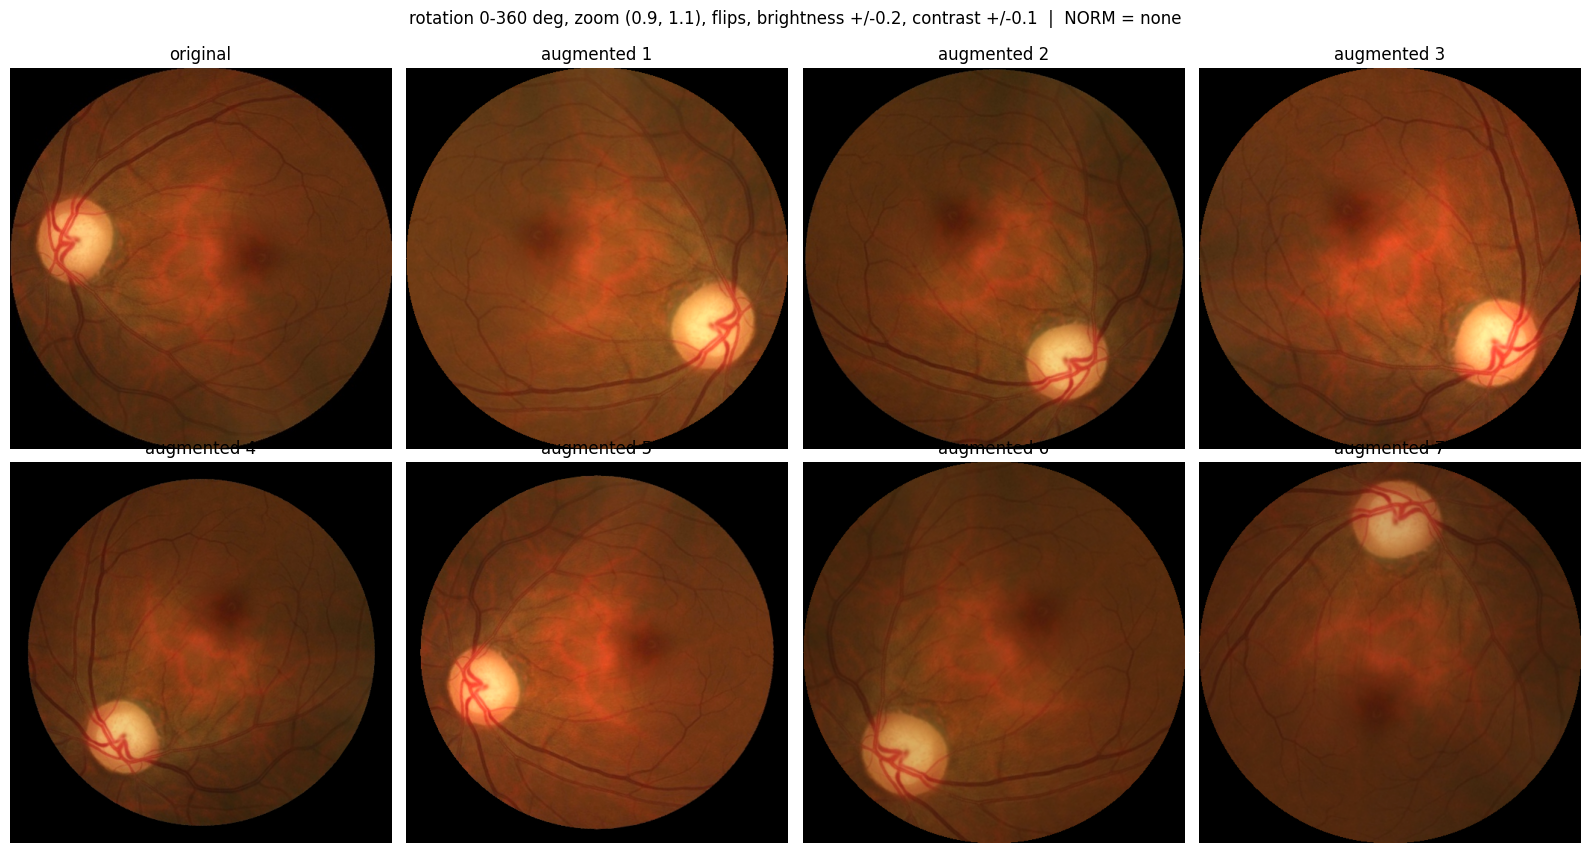

In [13]:
# 3.4 Augmentation preview: one training image, eight random versions
probe = cv2.imread(str(PROC / 'ddr' / train_df['id_code'].iloc[3]))
rng = np.random.default_rng(C.SEED)
views = [('original', probe)] + [(f'augmented {k}', augment(probe, rng)) for k in range(1, 8)]
if C.NORM == 'clahe':
    views = [(t, apply_clahe(v)) for t, v in views]
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, (title, img) in zip(axes.ravel(), views):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.set_title(title); ax.axis('off')
plt.suptitle(f'rotation 0-{C.ROTATION} deg, zoom {C.ZOOM}, flips, brightness +/-{C.BRIGHTNESS}, '
             f'contrast +/-{C.CONTRAST}  |  NORM = {C.NORM}', y=1.0)
plt.tight_layout(); plt.savefig(RUN_DIR / 'augmentation.png', dpi=120, bbox_inches='tight'); plt.show()

---
## 4. CNN architecture and transfer learning
EfficientNetV2-B0 pre-trained on ImageNet. **Phase 1** trains only the new head with the backbone
frozen. **Phase 2** unfreezes the top part of the backbone and fine-tunes with a 10x lower learning rate.

In [ ]:
# 4.1 Build the model
keras.backend.clear_session()
keras.utils.set_random_seed(C.SEED)

def build_model(head=C.HEAD):
    inp = keras.Input((C.IMG_SIZE, C.IMG_SIZE, 3), name='rgb_0_255')
    base = keras.applications.EfficientNetV2B0(include_top=False, weights=WEIGHTS,
                                               input_shape=(C.IMG_SIZE, C.IMG_SIZE, 3),
                                               include_preprocessing=True)   
    base.trainable = False
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    if head == 'dense':
        x = layers.BatchNormalization(name='head_bn')(x)
        x = layers.Dropout(C.DROPOUT, name='drop_1')(x)
        x = layers.Dense(256, activation='relu', name='dense_256')(x)
        x = layers.Dropout(C.DROPOUT, name='drop_2')(x)
    else:
        x = layers.Dropout(C.DROPOUT, name='drop_1')(x)
    out = layers.Dense(5, activation='softmax', dtype='float32', name='grade')(x)   
    return keras.Model(inp, out, name=f'effnetv2b0_{head}'), base

model, base = build_model()
model.summary()
n_train = sum(int(np.prod(v.shape)) for v in model.trainable_weights)
print(f'backbone layers: {len(base.layers)} | trainable now (head only): {n_train:,} of {model.count_params():,}')

probe_out = model.predict(np.random.uniform(0, 255, (2, C.IMG_SIZE, C.IMG_SIZE, 3)).astype('float32'), verbose=0)
assert probe_out.shape == (2, 5) and np.allclose(probe_out.sum(1), 1, atol=1e-3)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "effnetv2b0_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_0_255 (InputLayer)          │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 16, 16, 1280)   │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ grade (Dense)                   │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,653 (23.86 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

backbone layers: 270 | trainable now (head only): 331,781 of 6,253,653


2026-09-18 09:48:29.215105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:48:29.351114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:48:30.181107: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:48:30.322150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:48:31.128566: E external/local_xla/xla/stream_

In [ ]:
# 4.2 Loss function and callbacks
def sparse_focal(gamma=C.FOCAL_GAMMA):
    # focal loss: cross-entropy multiplied by (1 - p_true)^gamma
    def loss(y_true, y_pred):
        y = keras.ops.cast(keras.ops.reshape(y_true, (-1,)), 'int32')
        p = keras.ops.clip(keras.ops.cast(y_pred, 'float32'), 1e-7, 1.0)
        pt = keras.ops.sum(keras.ops.one_hot(y, 5) * p, axis=-1)
        return keras.ops.mean(-keras.ops.power(1.0 - pt, gamma) * keras.ops.log(pt))
    loss.__name__ = 'focal'
    return loss

LOSS_FN = sparse_focal() if C.LOSS == 'focal' else keras.losses.SparseCategoricalCrossentropy()
FIT_WEIGHTS = CLASS_WEIGHTS if C.LOSS == 'ce_weighted' else None

class CleanTrainMetrics(keras.callbacks.Callback):
    def __init__(self, ds, y):
        super().__init__(); self.ds, self.y = ds, y
    def on_epoch_end(self, epoch, logs=None):
        p = self.model.predict(self.ds, verbose=0)
        logs['clean_accuracy'] = float((p.argmax(1) == self.y).mean())
        logs['clean_loss'] = float(keras.ops.convert_to_numpy(LOSS_FN(self.y, p)))

def callbacks_for(phase):
    cbs = [CleanTrainMetrics(clean_ds, y_clean)]          
    if phase == 2:
        cbs += [keras.callbacks.ModelCheckpoint(str(RUN_DIR / 'best.weights.h5'), monitor='val_loss',
                                                save_best_only=True, save_weights_only=True, verbose=1),
                keras.callbacks.EarlyStopping(monitor='val_loss', patience=C.ES_PATIENCE,
                                              restore_best_weights=True, verbose=1),
                keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=C.RLR_FACTOR,
                                                  patience=C.RLR_PATIENCE, min_lr=1e-7, verbose=1)]
    cbs.append(keras.callbacks.CSVLogger(str(RUN_DIR / f'history_phase{phase}.csv')))
    return cbs

print('loss:', C.LOSS, '| class weights in fit:', FIT_WEIGHTS is not None)
print('phase 2 callbacks:', [type(c).__name__ for c in callbacks_for(2)])

loss: focal | class weights in fit: False
phase 2 callbacks: ['CleanTrainMetrics', 'ModelCheckpoint', 'EarlyStopping', 'ReduceLROnPlateau', 'CSVLogger']


In [16]:
# 4.3 Phase 1 - frozen backbone, train the head
model.compile(optimizer=keras.optimizers.Adam(C.PHASE1_LR), loss=LOSS_FN, metrics=['accuracy'])
t0 = time.time()
h1 = model.fit(train_ds, validation_data=val_ds, epochs=C.PHASE1_EPOCHS,
               class_weight=FIT_WEIGHTS, callbacks=callbacks_for(1), verbose=2)
print(f'phase 1: {time.time() - t0:.0f}s')

Epoch 1/5


2026-09-18 09:49:09.399701: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:49:09.575264: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:49:10.667384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:49:10.868343: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:49:12.051452: E external/local_xla/xla/stream_

280/280 - 207s - 738ms/step - accuracy: 0.6102 - loss: 0.7619 - val_accuracy: 0.7064 - val_loss: 0.3642 - clean_accuracy: 0.7060 - clean_loss: 0.3531
Epoch 2/5
280/280 - 90s - 322ms/step - accuracy: 0.6574 - loss: 0.4501 - val_accuracy: 0.7350 - val_loss: 0.3273 - clean_accuracy: 0.7380 - clean_loss: 0.2919
Epoch 3/5
280/280 - 88s - 315ms/step - accuracy: 0.6937 - loss: 0.3706 - val_accuracy: 0.7507 - val_loss: 0.3156 - clean_accuracy: 0.7640 - clean_loss: 0.2770
Epoch 4/5
280/280 - 88s - 314ms/step - accuracy: 0.6974 - loss: 0.3547 - val_accuracy: 0.7501 - val_loss: 0.3039 - clean_accuracy: 0.7600 - clean_loss: 0.2672
Epoch 5/5
280/280 - 89s - 319ms/step - accuracy: 0.7049 - loss: 0.3422 - val_accuracy: 0.7395 - val_loss: 0.3121 - clean_accuracy: 0.7620 - clean_loss: 0.2662
phase 1: 562s


In [ ]:
# 4.4 Phase 2 - unfreeze the top of the backbone and fine-tune
base.trainable = True
cut = int(len(base.layers) * (1 - C.UNFREEZE))
for layer in base.layers[:cut]:
    layer.trainable = False
n_train = sum(int(np.prod(v.shape)) for v in model.trainable_weights)
print(f'unfrozen backbone layers: {len(base.layers) - cut} of {len(base.layers)} | trainable params: {n_train:,}')

model.compile(optimizer=keras.optimizers.Adam(C.PHASE2_LR), loss=LOSS_FN, metrics=['accuracy'])
t0 = time.time()
h2 = model.fit(train_ds, validation_data=val_ds, initial_epoch=C.PHASE1_EPOCHS,
               epochs=C.PHASE1_EPOCHS + C.PHASE2_EPOCHS, class_weight=FIT_WEIGHTS,
               callbacks=callbacks_for(2), verbose=2)
train_minutes = (time.time() - t0) / 60
model.load_weights(RUN_DIR / 'best.weights.h5')          

hist = pd.concat([pd.DataFrame(h1.history), pd.DataFrame(h2.history)], ignore_index=True)
hist.insert(0, 'epoch', np.arange(1, len(hist) + 1))
hist['phase'] = [1] * len(h1.history['loss']) + [2] * len(h2.history['loss'])
hist.to_csv(RUN_DIR / 'history.csv', index=False)
p2 = hist[hist['phase'] == 2]
BEST_EPOCH = int(p2.loc[p2['val_loss'].idxmin(), 'epoch'])
print(f'phase 2: {train_minutes:.1f} min | epochs run: {len(hist)} | best epoch: {BEST_EPOCH}')

unfrozen backbone layers: 135 of 270 | trainable params: 4,941,037
Epoch 6/35


2026-09-18 09:58:57.374848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:58:57.593582: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:58:58.380997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:58:58.598162: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 09:58:59.901130: E external/local_xla/xla/stream_


Epoch 6: val_loss improved from None to 0.28146, saving model to /kaggle/working/runs/full_dense_none_focal_512/best.weights.h5

Epoch 6: finished saving model to /kaggle/working/runs/full_dense_none_focal_512/best.weights.h5
280/280 - 214s - 764ms/step - accuracy: 0.7035 - loss: 0.3552 - val_accuracy: 0.7619 - val_loss: 0.2815 - clean_accuracy: 0.7520 - clean_loss: 0.2591 - learning_rate: 1.0000e-04
Epoch 7/35

Epoch 7: val_loss improved from 0.28146 to 0.25216, saving model to /kaggle/working/runs/full_dense_none_focal_512/best.weights.h5

Epoch 7: finished saving model to /kaggle/working/runs/full_dense_none_focal_512/best.weights.h5
280/280 - 92s - 328ms/step - accuracy: 0.7481 - loss: 0.2940 - val_accuracy: 0.7815 - val_loss: 0.2522 - clean_accuracy: 0.7860 - clean_loss: 0.2438 - learning_rate: 1.0000e-04
Epoch 8/35

Epoch 8: val_loss improved from 0.25216 to 0.23130, saving model to /kaggle/working/runs/full_dense_none_focal_512/best.weights.h5

Epoch 8: finished saving model to

---
## 5. Training strategy
Validation set checked every epoch, early stopping and checkpointing on validation loss, learning rate
reduced on plateau, dropout and augmentation against overfitting. The **clean train** curve measures
training images with augmentation and dropout off, so it can be compared directly with validation.

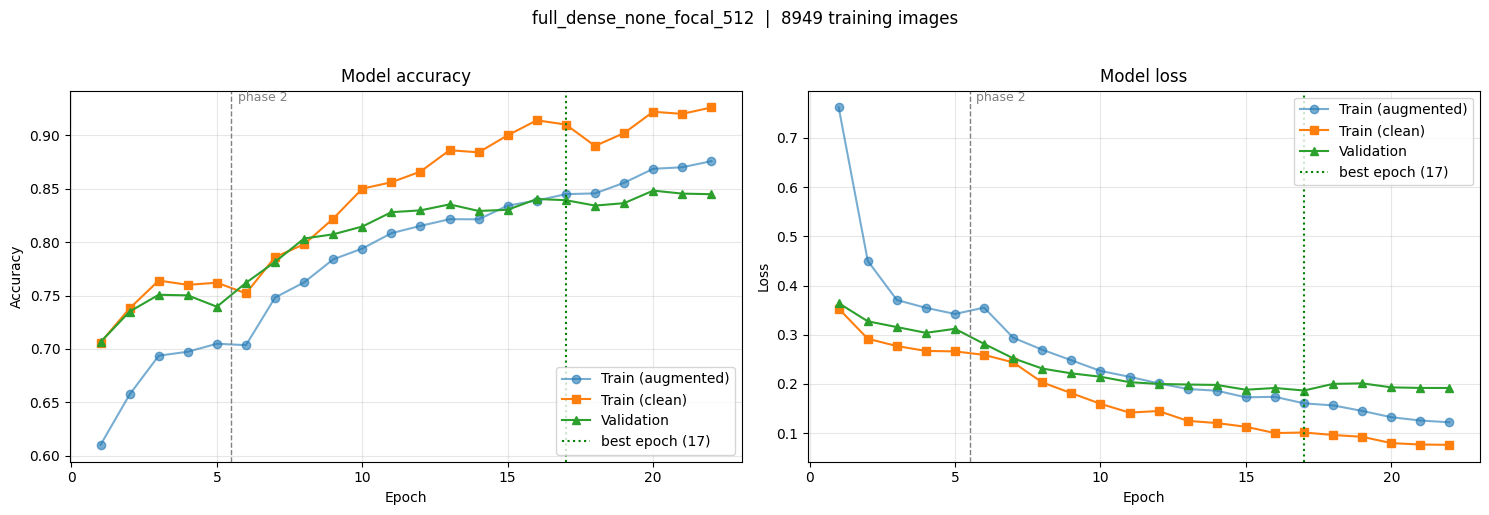

In [18]:
# 5.1 Accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(hist['epoch'], hist[metric], 'o-', label='Train (augmented)', alpha=0.6)
    ax.plot(hist['epoch'], hist[f'clean_{metric}'], 's-', label='Train (clean)')
    ax.plot(hist['epoch'], hist[f'val_{metric}'], '^-', label='Validation')
    ax.axvline(C.PHASE1_EPOCHS + 0.5, color='grey', ls='--', lw=1)
    ax.axvline(BEST_EPOCH, color='green', ls=':', lw=1.5, label=f'best epoch ({BEST_EPOCH})')
    ax.text(C.PHASE1_EPOCHS + 0.6, ax.get_ylim()[1], ' phase 2', va='top', fontsize=9, color='grey')
    ax.set_title(f'Model {metric}'); ax.set_xlabel('Epoch'); ax.set_ylabel(metric.title())
    ax.grid(alpha=0.3); ax.legend(loc='lower right' if metric == 'accuracy' else 'upper right')
plt.suptitle(f'{C.RUN_TAG}  |  {len(train_df)} training images', y=1.02)
plt.tight_layout(); plt.savefig(RUN_DIR / 'curves.png', dpi=150, bbox_inches='tight'); plt.show()

In [19]:
# 5.2 Gap between training and validation
gap = hist[['epoch', 'phase', 'accuracy', 'clean_accuracy', 'val_accuracy', 'val_loss']].copy()
gap['aug train - val'] = gap['accuracy'] - gap['val_accuracy']
gap['clean train - val'] = gap['clean_accuracy'] - gap['val_accuracy']
if 'learning_rate' in hist:
    gap['lr'] = hist['learning_rate']
print(gap.round(4).to_string(index=False))
best = gap[gap['epoch'] == BEST_EPOCH].iloc[0]
print(f"\nat the best epoch ({BEST_EPOCH}): clean train {best['clean_accuracy']:.3f} | "
      f"val {best['val_accuracy']:.3f} | real gap {best['clean train - val']:+.3f} | "
      f"gap caused by augmentation and dropout {best['clean_accuracy'] - best['accuracy']:+.3f}")

 epoch  phase  accuracy  clean_accuracy  val_accuracy  val_loss  aug train - val  clean train - val     lr
     1      1    0.6102           0.706        0.7064    0.3642          -0.0962            -0.0004    NaN
     2      1    0.6574           0.738        0.7350    0.3273          -0.0776             0.0030    NaN
     3      1    0.6937           0.764        0.7507    0.3156          -0.0570             0.0133    NaN
     4      1    0.6974           0.760        0.7501    0.3039          -0.0527             0.0099    NaN
     5      1    0.7049           0.762        0.7395    0.3121          -0.0346             0.0225    NaN
     6      2    0.7035           0.752        0.7619    0.2815          -0.0584            -0.0099 0.0001
     7      2    0.7481           0.786        0.7815    0.2522          -0.0334             0.0045 0.0001
     8      2    0.7623           0.798        0.8034    0.2313          -0.0410            -0.0054 0.0001
     9      2    0.7839           0.8

---
## 6. Evaluation
All numbers use the best checkpoint. The DDR test split and IDRiD were never used to choose anything.

DDR test (1788 images): accuracy 0.8300 | QWK 0.8508 | macro F1 0.6748

                  precision    recall  f1-score   support

           No_DR      0.849     0.972     0.906       897
            Mild      0.409     0.293     0.342        92
        Moderate      0.881     0.717     0.791       637
          Severe      0.486     0.545     0.514        33
Proliferative_DR      0.791     0.853     0.821       129

        accuracy                          0.830      1788
       macro avg      0.683     0.676     0.675      1788
    weighted avg      0.827     0.830     0.823      1788

                       pred_No_DR  pred_Mild  pred_Moderate  pred_Severe  pred_Proliferative_DR
true_No_DR                    872          7             16            0                      2
true_Mild                      45         27             20            0                      0
true_Moderate                 107         32            457           16                     25
true_Severe        

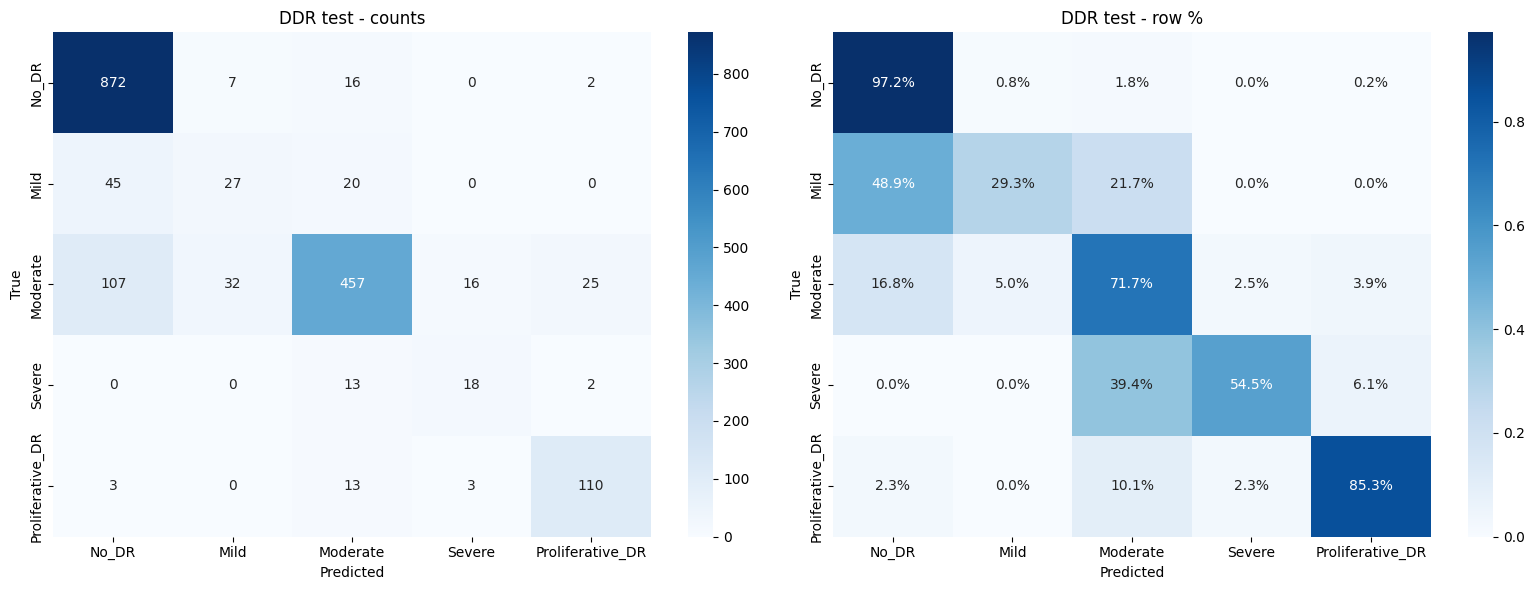

In [ ]:
# 6.1 DDR test set: metrics, classification report, confusion matrix
def metrics(y, p):
    yh = p.argmax(1)
    ref_t, ref_p = y >= 2, yh >= 2                         
    rec = recall_score(y, yh, labels=range(5), average=None, zero_division=0)
    out = {'accuracy': accuracy_score(y, yh), 'QWK': cohen_kappa_score(y, yh, weights='quadratic'),
           'macro F1': f1_score(y, yh, average='macro', labels=range(5), zero_division=0),
           'referable sens': (ref_t & ref_p).sum() / max(ref_t.sum(), 1),
           'referable spec': (~ref_t & ~ref_p).sum() / max((~ref_t).sum(), 1),
           'referable AUC': roc_auc_score(ref_t, p[:, 2:].sum(1)) if 0 < ref_t.sum() < len(y) else np.nan}
    out.update({f'recall {LABELS[i]}': rec[i] for i in range(5)})
    return {k: float(v) for k, v in out.items()}

def plot_cm(y, yh, title, fname):
    cm = confusion_matrix(y, yh, labels=range(5))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=LABELS, yticklabels=LABELS)
    sns.heatmap(cm / cm.sum(1, keepdims=True).clip(min=1), annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
                xticklabels=LABELS, yticklabels=LABELS)
    for ax, t in zip(axes, ['counts', 'row %']):
        ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(f'{title} - {t}')
    plt.tight_layout(); plt.savefig(RUN_DIR / fname, dpi=130, bbox_inches='tight'); plt.show()

p_val  = model.predict(val_ds, verbose=0)
p_test = model.predict(test_ds, verbose=0)
R = {'val': metrics(y_val, p_val), 'test': metrics(y_test, p_test)}

print(f"DDR test ({len(y_test)} images): accuracy {R['test']['accuracy']:.4f} | QWK {R['test']['QWK']:.4f} | "
      f"macro F1 {R['test']['macro F1']:.4f}\n")
print(classification_report(y_test, p_test.argmax(1), labels=range(5), target_names=LABELS, digits=3, zero_division=0))
cm = confusion_matrix(y_test, p_test.argmax(1), labels=range(5))
print(pd.DataFrame(cm, index=[f'true_{l}' for l in LABELS], columns=[f'pred_{l}' for l in LABELS]).to_string())

plot_cm(y_test, p_test.argmax(1), 'DDR test', 'cm_test.png')

In [ ]:
# 6.2 IDRiD external test
p_idrid = model.predict(idrid_ds, verbose=0)
R['idrid'] = metrics(y_idrid, p_idrid)
print(classification_report(y_idrid, p_idrid.argmax(1), labels=range(5), target_names=LABELS, digits=3, zero_division=0))
cm = confusion_matrix(y_test, p_test.argmax(1), labels=range(5))
print(pd.DataFrame(cm, index=[f'true_{l}' for l in LABELS], columns=[f'pred_{l}' for l in LABELS]).to_string())
plot_cm(y_idrid, p_idrid.argmax(1), 'IDRiD external', 'cm_idrid.png')

compare = pd.DataFrame(R).T
print(compare[['accuracy', 'QWK', 'macro F1', 'referable sens', 'referable spec', 'referable AUC']
              + [f'recall {l}' for l in LABELS]].round(4).T.to_string())

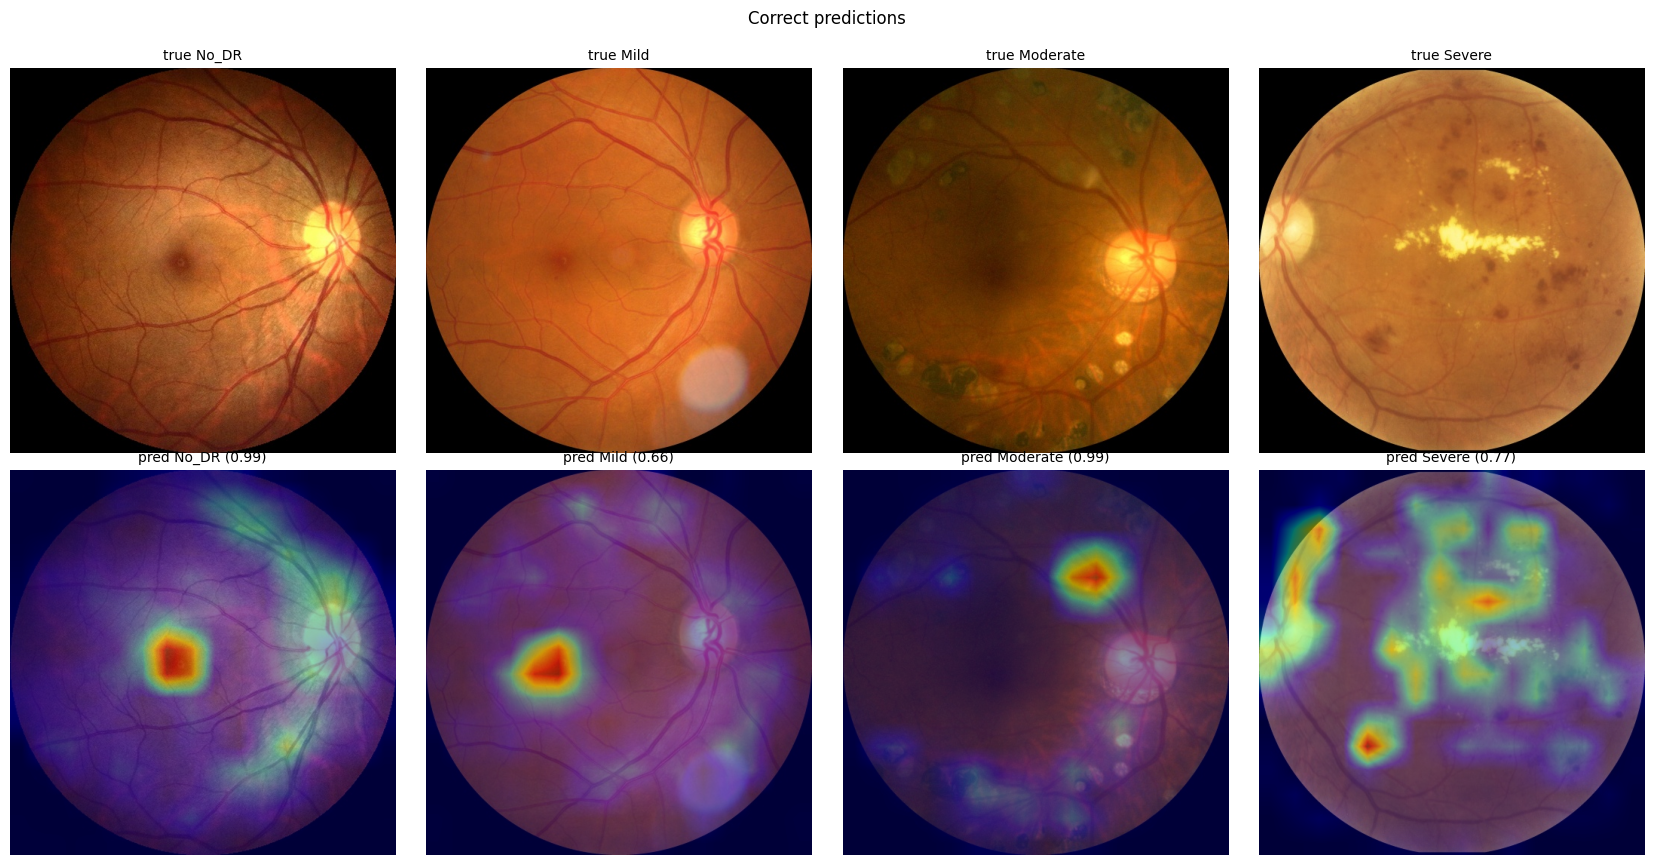

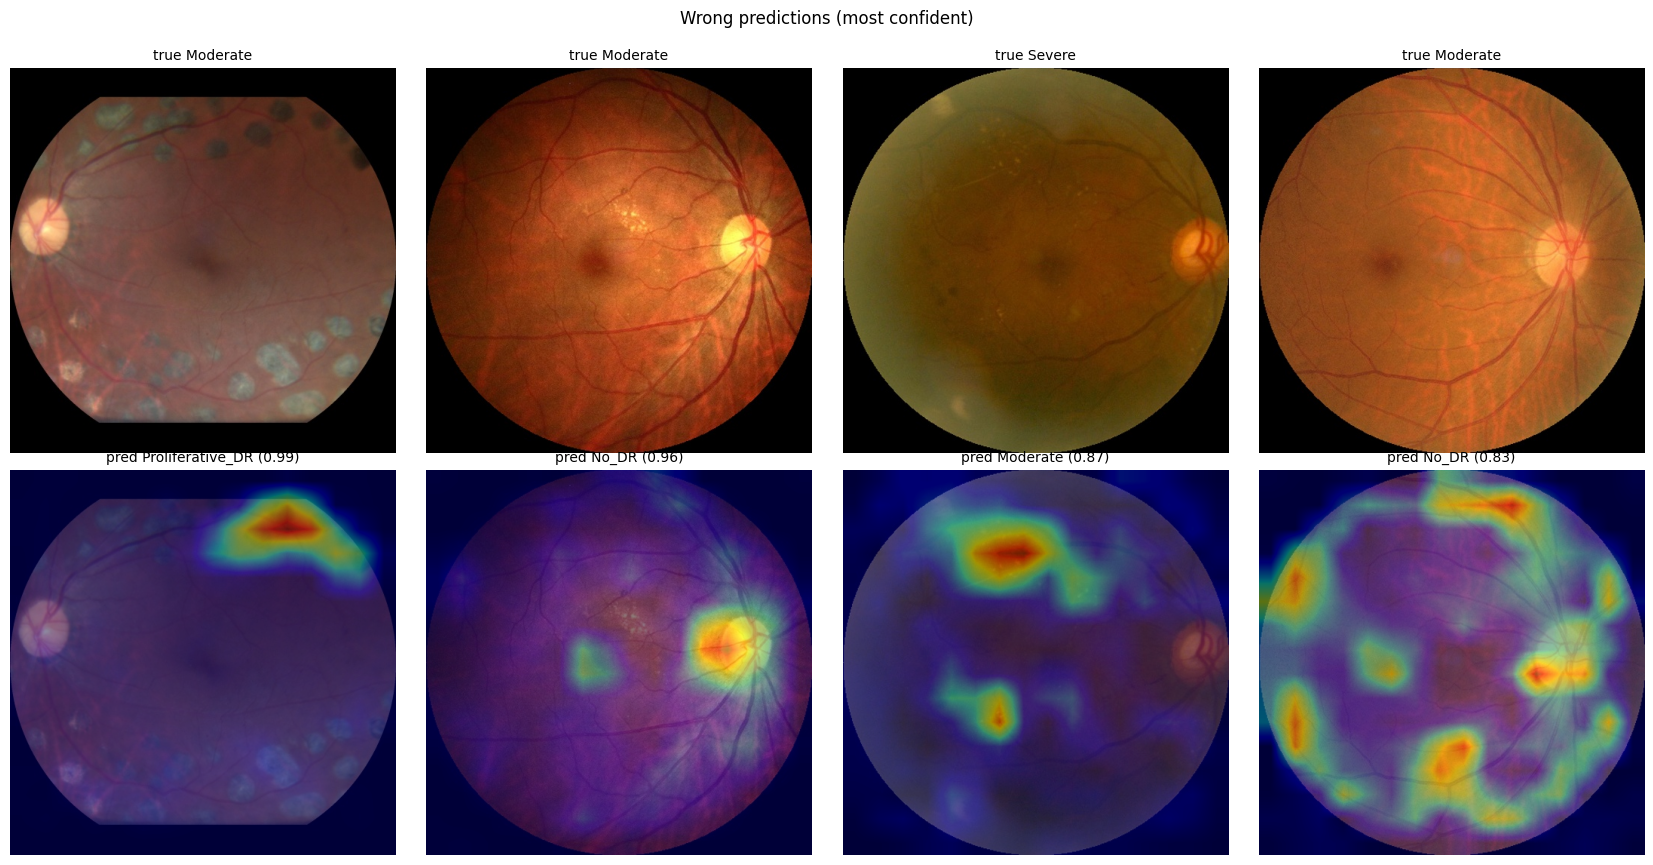

In [22]:
# 6.3 Grad-CAM: which parts of the retina drove the prediction
feat_model = keras.Model(base.input, base.output)
head = model.layers[[l.name for l in model.layers].index('gap'):]

def gradcam(x):
    x = tf.constant(x, tf.float32)
    with tf.GradientTape() as tape:
        conv = feat_model(x, training=False)
        tape.watch(conv)
        z = conv
        for layer in head:
            z = layer(z, training=False)
        cls = tf.argmax(z, axis=1)
        score = tf.gather(z, cls, axis=1, batch_dims=1)
    g = tape.gradient(score, conv)
    cam = tf.nn.relu(tf.reduce_sum(tf.reduce_mean(g, axis=(1, 2), keepdims=True) * conv, -1))
    return (cam / (tf.reduce_max(cam, axis=(1, 2), keepdims=True) + 1e-8)).numpy(), z.numpy()

conf, pred = p_test.max(1), p_test.argmax(1)
right = [np.where((y_test == c) & (pred == c))[0] for c in range(5)]
picks_ok = [idx[np.argmax(conf[idx])] for idx in right if len(idx)][:4]
wrong = np.where(pred != y_test)[0]
picks_bad = list(wrong[np.argsort(-conf[wrong])][:4])

for title, picks in [('Correct predictions', picks_ok), ('Wrong predictions (most confident)', picks_bad)]:
    imgs = np.stack([load_image(PROC / 'ddr' / test_df['id_code'].iloc[i]) for i in picks])
    cams, probs = gradcam(imgs)
    assert np.allclose(probs, p_test[picks], atol=2e-3), 'Grad-CAM path does not match the model'
    fig, axes = plt.subplots(2, len(picks), figsize=(4.2 * len(picks), 8.6), squeeze=False)
    for k, i in enumerate(picks):
        rgb = imgs[k].astype(np.uint8)
        axes[0, k].imshow(rgb); axes[0, k].set_title(f'true {LABELS[y_test[i]]}', fontsize=10)
        axes[1, k].imshow(rgb)
        axes[1, k].imshow(cv2.resize(cams[k], (C.IMG_SIZE, C.IMG_SIZE)), cmap='jet', alpha=0.45)
        axes[1, k].set_title(f'pred {LABELS[pred[i]]} ({conf[i]:.2f})', fontsize=10)
        axes[0, k].axis('off'); axes[1, k].axis('off')
    plt.suptitle(title, y=1.0)
    plt.tight_layout(); plt.savefig(RUN_DIR / f"gradcam_{'ok' if picks is picks_ok else 'bad'}.png",
                                    dpi=120, bbox_inches='tight'); plt.show()

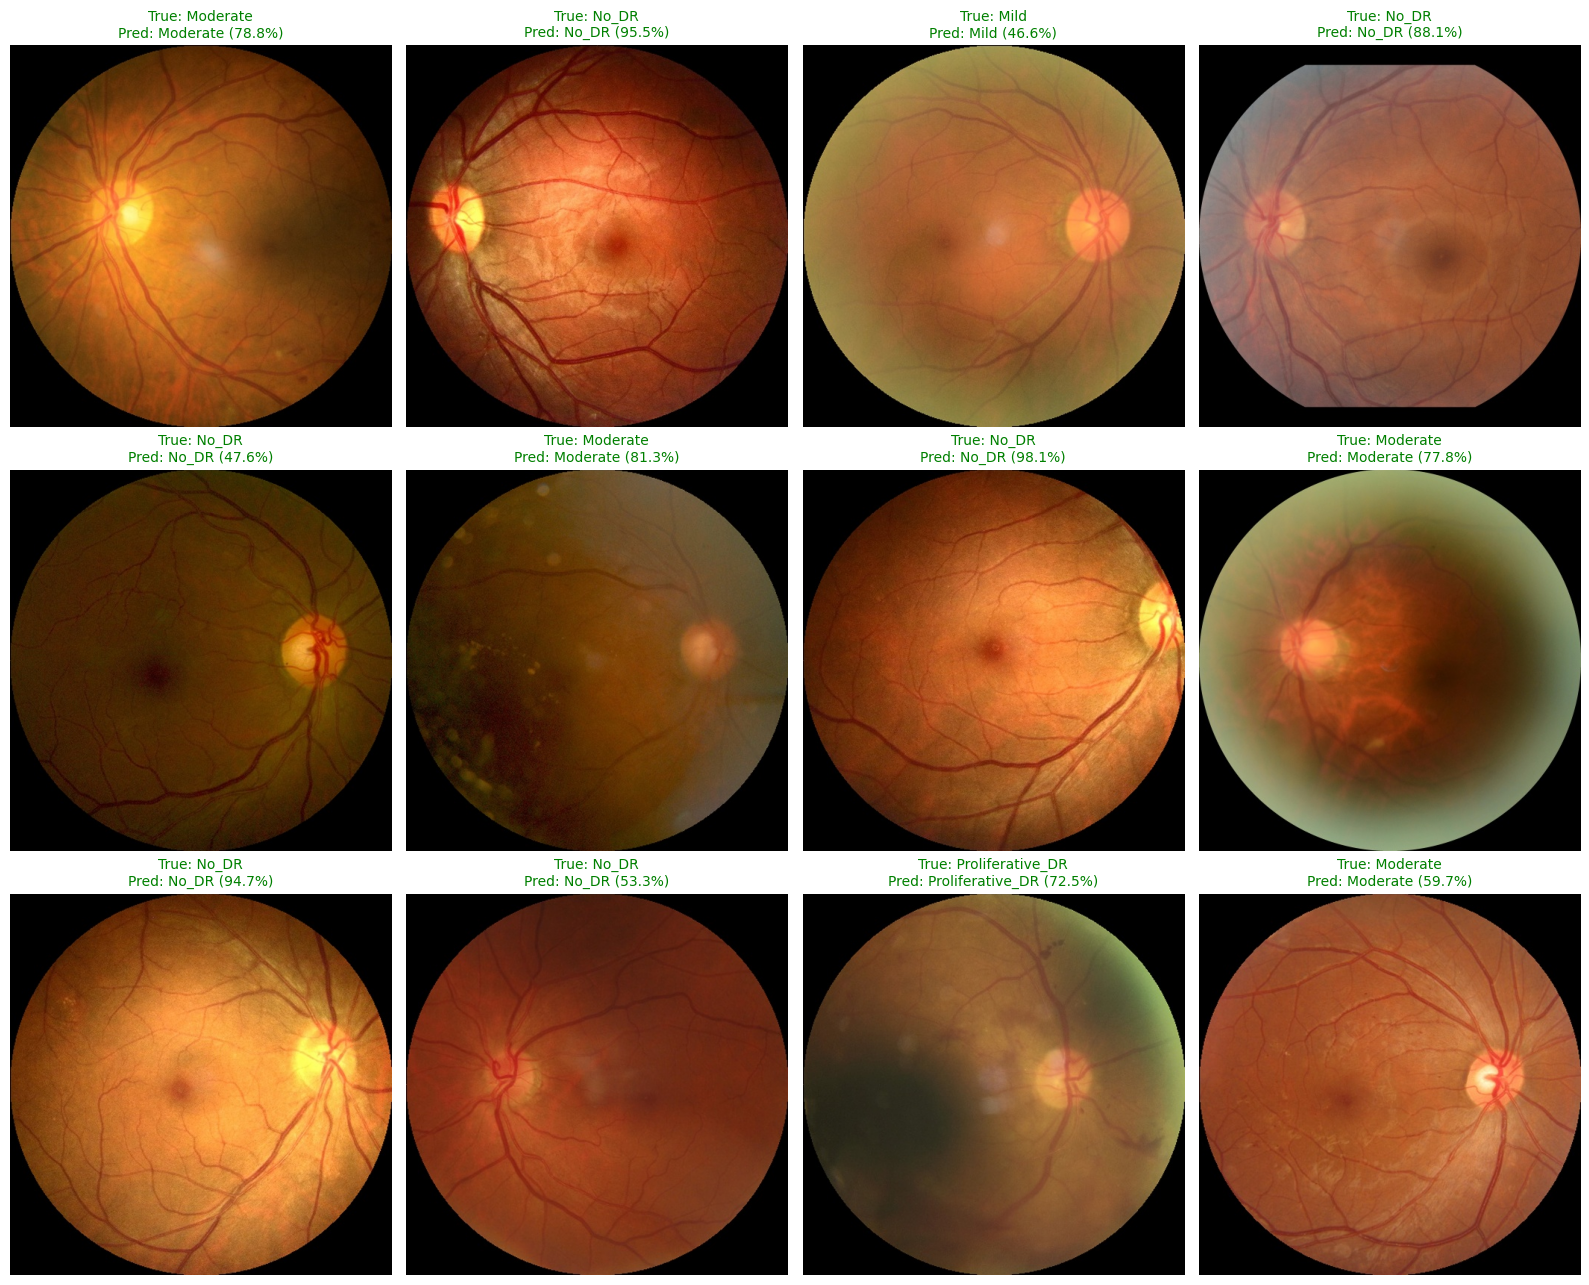

2026-09-18 10:29:36.804824: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:29:36.939518: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:29:37.817673: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:29:37.957168: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-18 10:29:38.834719: E external/local_xla/xla/stream_

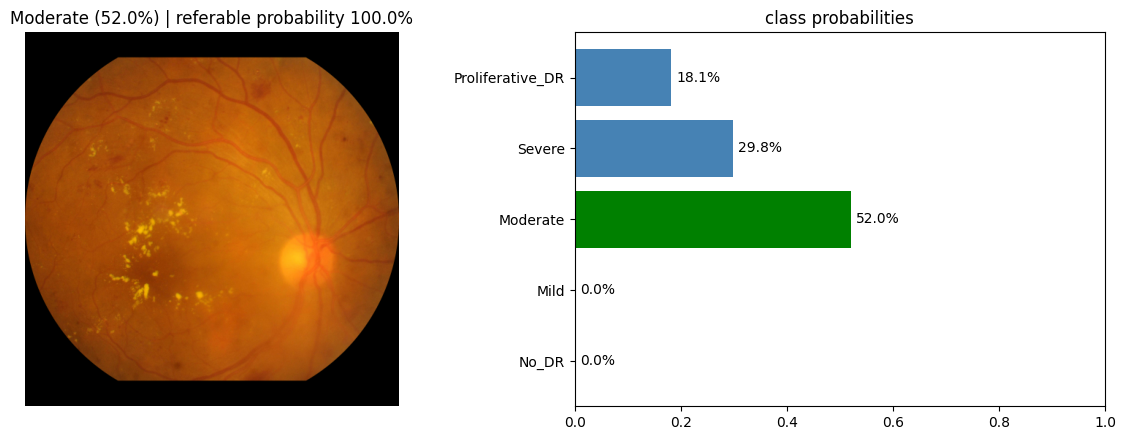

{'grade': 'Moderate', 'confidence': 0.5201812982559204, 'referable_prob': 0.9997149109840393, 'probabilities': {'No_DR': 0.0, 'Mild': 0.0003000000142492354, 'Moderate': 0.5202000141143799, 'Severe': 0.29820001125335693, 'Proliferative_DR': 0.18129999935626984}}


In [ ]:
# 6.4 Prediction grid and single-image inference
rng = np.random.default_rng(C.SEED)
sel = rng.choice(len(test_df), 12, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(16, 13))
for ax, i in zip(axes.ravel(), sel):
    ok = p_test[i].argmax() == y_test[i]
    ax.imshow(load_image(PROC / 'ddr' / test_df['id_code'].iloc[i]).astype(np.uint8))
    ax.set_title(f'True: {LABELS[y_test[i]]}\nPred: {LABELS[p_test[i].argmax()]} ({p_test[i].max():.1%})',
                 color='green' if ok else 'red', fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.savefig(RUN_DIR / 'predictions.png', dpi=120, bbox_inches='tight'); plt.show()

def predict_single_image(path, raw=True):
    img = preprocess(path) if raw else cv2.imread(str(path))
    assert img is not None, f'could not read or find a retina in {path}'
    if C.NORM == 'clahe':
        img = apply_clahe(img)
    x = cv2.cvtColor(cv2.resize(img, (C.IMG_SIZE, C.IMG_SIZE)), cv2.COLOR_BGR2RGB).astype(np.float32)
    p = model.predict(x[None], verbose=0)[0]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].imshow(x.astype(np.uint8)); axes[0].axis('off')
    axes[0].set_title(f'{LABELS[p.argmax()]} ({p.max():.1%}) | referable probability {p[2:].sum():.1%}')
    axes[1].barh(LABELS, p, color=['green' if i == p.argmax() else 'steelblue' for i in range(5)])
    axes[1].set_xlim(0, 1); axes[1].set_title('class probabilities')
    for i, v in enumerate(p):
        axes[1].text(v + 0.01, i, f'{v:.1%}', va='center')
    plt.tight_layout(); plt.show()
    return {'grade': LABELS[p.argmax()], 'confidence': float(p.max()), 'referable_prob': float(p[2:].sum()),
            'probabilities': dict(zip(LABELS, p.round(4).tolist()))}

print(predict_single_image(IDRID_IMG / f"{idr['id_code'].iloc[0]}.jpg"))

In [24]:
# 6.5 Referral threshold (fitted on validation, applied to test and IDRiD)
# refer when P(Moderate) + P(Severe) + P(PDR) >= t; choose the highest t that still catches 95% on validation
def referral(y, p, t):
    ref_t, ref_p = y >= 2, p[:, 2:].sum(1) >= t
    return {'sensitivity': (ref_t & ref_p).sum() / ref_t.sum(), 'specificity': (~ref_t & ~ref_p).sum() / (~ref_t).sum(),
            'missed': int((ref_t & ~ref_p).sum()), 'referred %': 100 * ref_p.mean()}

grid = np.round(np.arange(0.01, 1.0, 0.01), 2)
ok = [t for t in grid if referral(y_val, p_val, t)['sensitivity'] >= 0.95]
REF_T = float(max(ok)) if ok else 0.5
rows = {f'{name} @ {t}': referral(y, p, t) for name, y, p in
        [('val', y_val, p_val), ('test', y_test, p_test), ('IDRiD', y_idrid, p_idrid)] for t in (0.5, REF_T)}
print('referral threshold:', REF_T)
print(pd.DataFrame(rows).T.round(4).to_string())
for name, y, p in [('test', y_test, p_test), ('idrid', y_idrid, p_idrid)]:
    R[name].update({f'referral sens @thr': referral(y, p, REF_T)['sensitivity'],
                    f'referral spec @thr': referral(y, p, REF_T)['specificity']})

referral threshold: 0.23
              sensitivity  specificity  missed  referred %
val @ 0.5          0.8055       0.9601   157.0     38.5994
val @ 0.23         0.9554       0.7403    36.0     57.4230
test @ 0.5         0.7860       0.9697   171.0     36.8009
test @ 0.23        0.9549       0.7533    36.0     56.3199
IDRiD @ 0.5        0.9618       0.7801    12.0     73.1868
IDRiD @ 0.23       0.9968       0.4894     1.0     84.6154


In [25]:
# 6.6 Save the run and print a summary
best_row = hist[hist['epoch'] == BEST_EPOCH].iloc[0]
results = {'run_tag': C.RUN_TAG, 'split_id': SPLIT_ID, 'train_images': len(train_df),
           'epochs_run': int(len(hist)), 'best_epoch': BEST_EPOCH, 'phase2_minutes': round(train_minutes, 1),
           'best_train_acc_clean': float(best_row['clean_accuracy']), 'best_val_acc': float(best_row['val_accuracy']),
           'gap_clean_minus_val': float(best_row['clean_accuracy'] - best_row['val_accuracy']),
           'referral_threshold': REF_T, **{f'{s}_{k}': v for s in R for k, v in R[s].items()}}
cfg = {k: (list(v) if isinstance(v, tuple) else v) for k, v in vars(Config).items() if not k.startswith('_')}
(RUN_DIR / 'results.json').write_text(json.dumps(results, indent=2, default=float))
(RUN_DIR / 'config.json').write_text(json.dumps(cfg, indent=2))
np.save(RUN_DIR / 'probs_test.npy', p_test); np.save(RUN_DIR / 'probs_idrid.npy', p_idrid)

print('=' * 70)
print('DIABETIC RETINOPATHY - RUN SUMMARY')
print('=' * 70)
print(f'run            : {C.RUN_TAG}')
print(f'data           : {len(train_df)} train | {len(val_df)} val | {len(test_df)} test | {len(idr)} IDRiD')
print(f'model          : EfficientNetV2-B0 + {C.HEAD} head | {C.IMG_SIZE}px | NORM={C.NORM} | loss={C.LOSS}')
print(f'training       : {len(hist)} epochs (best {BEST_EPOCH}) | phase 2 {train_minutes:.1f} min')
print(f"curves         : clean train {best_row['clean_accuracy']:.3f} vs val {best_row['val_accuracy']:.3f} at best epoch")
for s, name in [('test', 'DDR test'), ('idrid', 'IDRiD')]:
    print(f"{name:15s}: accuracy {R[s]['accuracy']:.4f} | QWK {R[s]['QWK']:.4f} | macro F1 {R[s]['macro F1']:.4f} | "
          f"referral sens {R[s]['referral sens @thr']:.3f} @ {REF_T}")
print('saved to       :', RUN_DIR)
print('files          :', sorted(p.name for p in RUN_DIR.iterdir()))

DIABETIC RETINOPATHY - RUN SUMMARY
run            : full_dense_none_focal_512
data           : 8949 train | 1785 val | 1788 test | 455 IDRiD
model          : EfficientNetV2-B0 + dense head | 512px | NORM=none | loss=focal
training       : 22 epochs (best 17) | phase 2 27.8 min
curves         : clean train 0.910 vs val 0.839 at best epoch
DDR test       : accuracy 0.8300 | QWK 0.8508 | macro F1 0.6748 | referral sens 0.955 @ 0.23
IDRiD          : accuracy 0.6769 | QWK 0.8075 | macro F1 0.5991 | referral sens 0.997 @ 0.23
saved to       : /kaggle/working/runs/full_dense_none_focal_512
files          : ['augmentation.png', 'best.weights.h5', 'cm_idrid.png', 'cm_test.png', 'config.json', 'curves.png', 'gradcam_bad.png', 'gradcam_ok.png', 'history.csv', 'history_phase1.csv', 'history_phase2.csv', 'predictions.png', 'probs_idrid.npy', 'probs_test.npy', 'results.json']


                           train_images  epochs_run  best_epoch  best_val_acc  gap_clean_minus_val  test_accuracy  test_QWK  test_macro F1  test_recall Mild  test_recall Severe  idrid_accuracy  idrid_QWK  test_referral sens @thr        split_id
run_tag                                                                                                                                                                                                                                             
full_dense_none_focal_512          8949          22          17        0.8392               0.0708         0.8300    0.8508         0.6748            0.2935              0.5455          0.6769     0.8075                   0.9549  ddr_splits_7x6
2000_dense_none_focal_512          2000          19          14        0.6129               0.1751         0.6152    0.7572         0.5198            0.6630              0.6364          0.4857     0.7714                   0.9637  ddr_splits_7x6


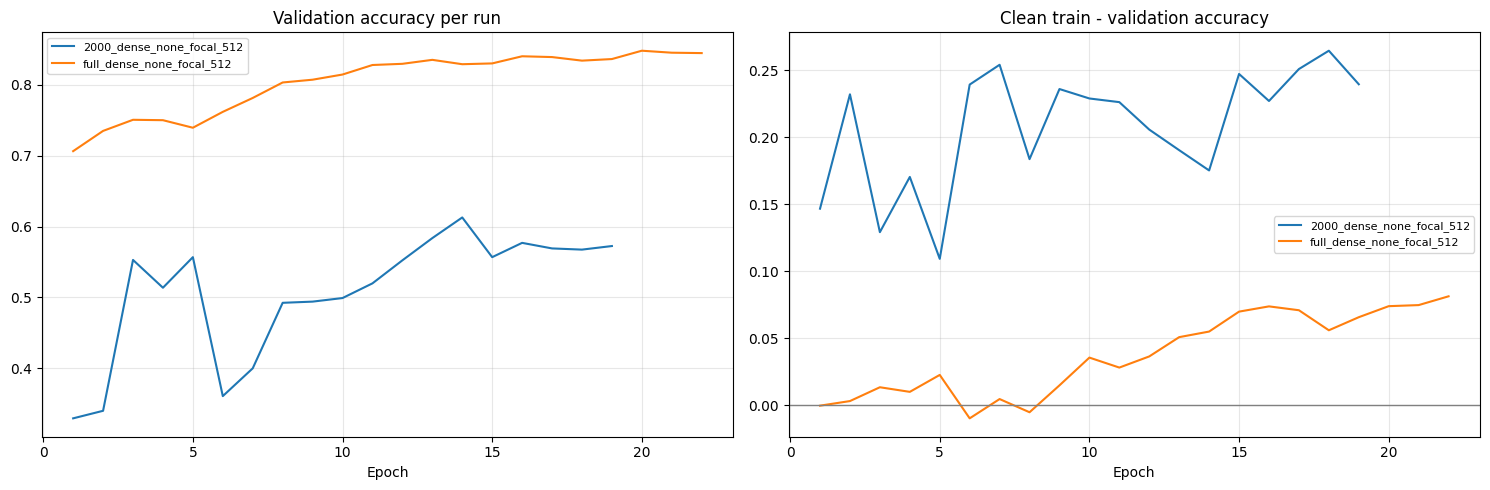

In [ ]:
# 6.7 Compare all runs (reads every runs/*/results.json in working and attached inputs)
found = {}
for path in list(RUNS.glob('*/results.json')) + list(INPUT.rglob('runs/*/results.json')):
    r = json.loads(path.read_text())
    found.setdefault(r['run_tag'], (r, path.parent))       
if not found:
    print('no finished runs yet')
else:
    df_runs = pd.DataFrame([r for r, _ in found.values()]).set_index('run_tag')
    cols = ['train_images', 'epochs_run', 'best_epoch', 'best_val_acc', 'gap_clean_minus_val',
            'test_accuracy', 'test_QWK', 'test_macro F1', 'test_recall Mild', 'test_recall Severe',
            'idrid_accuracy', 'idrid_QWK', 'test_referral sens @thr', 'split_id']
    df_runs = df_runs[[c for c in cols if c in df_runs]].sort_values('test_QWK', ascending=False)
    print(df_runs.round(4).to_string())
    if df_runs['split_id'].nunique() > 1:
        print('\nWARNING: runs use different splits - compare only rows with the same split_id')

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for tag, (_, folder) in sorted(found.items()):
        hh = pd.read_csv(folder / 'history.csv')
        axes[0].plot(hh['epoch'], hh['val_accuracy'], label=tag)
        axes[1].plot(hh['epoch'], hh['clean_accuracy'] - hh['val_accuracy'], label=tag)
    axes[0].set_title('Validation accuracy per run'); axes[1].set_title('Clean train - validation accuracy')
    axes[1].axhline(0, color='grey', lw=1)
    for ax in axes:
        ax.set_xlabel('Epoch'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(RUNS / 'comparison.png', dpi=130, bbox_inches='tight'); plt.show()